## 额外练习：离散时间系统实现

我为你设计了一个**简单却有教育意义的题目**：实现一个离散时间的**一维粒子运动模拟器**（1D Particle in a Force Field）。这个题目结合了基本物理（位置和速度的离散更新）和控制（可选添加输入力），适合初学者逐步构建。它与机器人相关（类似于简化版的机械臂关节动力学），但不复杂。你可以用 Python 实现，逐步添加功能。如果完成这个，你可以扩展到更复杂的系统如离散 PID 控制器或倒立摆。

下面是题目的详细描述，包括背景、要求、步骤指导和参考代码框架。慢慢来，按照步骤实现；如果卡住，贴你的代码或错误，我帮你调试！

#### 题目背景
- **问题描述**：模拟一个一维粒子（particle）在力场中的运动。粒子有位置 \( x \) 和速度 \( v \)，受外部输入力 \( u \)（control input）和恒定重力 \( g = -9.8 \) m/s² 影响。
- **离散模型**：使用 Euler 前向积分（forward Euler）离散化连续动力学：
  - 连续形式： \( \dot{x} = v \), \( \dot{v} = u + g \)。
  - 离散形式（时间步 \( \Delta t = 0.01 \) s）： \( x[k+1] = x[k] + v[k] \Delta t \), \( v[k+1] = v[k] + (u[k] + g) \Delta t \)。
- **目标**：用 Drake 自定义一个离散 `LeafSystem`，模拟粒子的状态演化。添加输入端口（u）和输出端口（x, v），然后构建 diagram 并运行模拟。最终可视化轨迹（e.g., 用 Matplotlib 画位置 vs 时间）。

- **为什么这个题目适合**？
  - 简单：只需基本线性代数和离散更新。
  - 教育性：练习 Drake 的系统构建、状态声明、端口和模拟。
  - 扩展性：完成后，你可以添加噪声、控制器（e.g., 使粒子跟踪目标位置），或整合到 MultibodyPlant（e.g., 模拟机械臂关节）。

#### 要求
- **输入**：一个 scalar 输入端口（u：外部力，double 类型）。
- **输出**：一个 vector 输出端口（[x, v]：位置和速度，BasicVector(2)）。
- **状态**：离散状态向量（[x, v]，初始化为 [0, 0]）。
- **模拟**：运行 10 秒，应用正弦波输入力 $u(t) = \sin(2\pi t)$，记录轨迹并 plot。
- **约束**：用 Python 接口；时间步固定为 0.01 s；无连续状态（纯离散系统）。
- **bonus**（可选扩展）：添加随机噪声到速度更新，模拟不确定性。

#### 实现步骤（逐步指导）
1. **安装/导入**：确保有 Drake（pip install drake）。导入必要模块：
   ```python
   import numpy as np
   from pydrake.systems.framework import LeafSystem, BasicVector, DiagramBuilder
   from pydrake.systems.primitives import ConstantVectorSource
   from pydrake.simulation import Simulator
   import matplotlib.pyplot as plt
   ```

2. **定义自定义离散系统类**：
   - 继承 `LeafSystem`。
   - 在 `__init__` 中：声明离散状态（AbstractState 或 NumericState）、输入端口（DeclareVectorInputPort）和输出端口（DeclareVectorOutputPort）。
   - 重写 `DoCalcDiscreteVariableUpdates`：计算下一状态（x[k+1], v[k+1]）。
   - 重写 `DoCalcVectorOutput`：输出当前 [x, v]。

3. **构建 Diagram**：
   - 用 DiagramBuilder 添加你的系统和一个输入源（e.g., ConstantVectorSource 或自定义 sin 输入）。
   - 连接端口。

4. **运行模拟**：
   - 创建 Simulator，设置初始状态，AdvanceTo(10.0)。
   - 记录输出轨迹。

5. **可视化**：用 plt 画 x(t) 和 v(t)。

#### 参考代码框架（填空式，供你完成）
```python
class DiscreteParticleSystem(LeafSystem):
    def __init__(self, dt=0.01, g=-9.8):
        super().__init__()
        self.dt = dt
        self.g = g
        
        # TODO: 声明离散状态（vector [x, v]，初始 [0, 0]）
        self.state_index = self.DeclareDiscreteState(2)  # 提示：DeclareDiscreteState(2) 返回索引
        
        # TODO: 声明输入端口（scalar u）
        self.DeclareVectorInputPort("u", BasicVector(1))  # 提示：大小1
        
        # TODO: 声明输出端口（vector [x, v]）
        self.DeclareVectorOutputPort("state", BasicVector(2), self.DoCalcVectorOutput)  # 提示：绑定 DoCalcVectorOutput
        
        # TODO: 声明离散更新事件（每 dt 秒更新一次）
        self.DeclarePeriodicDiscreteUpdateEvent(period_sec=dt, offset_sec=0.0, update=self.DoCalcDiscreteVariableUpdates)

    def DoCalcDiscreteVariableUpdates(self, context, events, discrete_state):
        # 获取当前状态和输入
        current_state = context.get_discrete_state(self.state_index).value()  # [x, v]
        u = self.get_input_port(0).Eval(context)[0]  # scalar u
        
        # TODO: 计算下一状态
        x_next = current_state[0] + current_state[1] * self.dt  # x[k+1] = x[k] + v[k] * dt
        v_next = ...  # 完成：v[k+1] = v[k] + (u + g) * dt
        
        # 更新 discrete_state
        discrete_state.get_mutable_vector(self.state_index).SetFromVector([x_next, v_next])

    def DoCalcVectorOutput(self, context, unused, state, output):
        # TODO: 输出当前 [x, v]
        current_state = context.get_discrete_state(self.state_index).value()
        output.SetFromVector(current_state)  # 设置输出

def run_simulation():
    builder = DiagramBuilder()
    
    # 添加你的系统
    particle = builder.AddSystem(DiscreteParticleSystem(dt=0.01))
    
    # TODO: 添加输入源（e.g., sin wave；用 ConstantVectorSource 或自定义系统）
    # 提示：对于 sin(t)，你可以自定义另一个 LeafSystem 输出 sin(2*pi*t)
    input_source = builder.AddSystem(ConstantVectorSource(np.array([0.0])))  # 先用常量0，bonus 改 sin
    input_source = builder.AddSystem(SinInputSystem())

    
    # 连接
    builder.Connect(input_source.get_output_port(0), particle.GetInputPort("u"))
    
    # 构建 diagram
    diagram = builder.Build()
    
    # 创建 simulator
    simulator = Simulator(diagram)
    context = simulator.get_mutable_context()
    
    # TODO: 设置初始状态（e.g., [0, 10]）
    # 提示：context.SetDiscreteState(particle.state_index, np.array([0.0, 10.0]))
    
    # 运行模拟并记录轨迹
    times = []
    states = []
    simulator.Initialize()
    for t in np.arange(0.0, 10.0, 0.01):
        simulator.AdvanceTo(t)
        state = particle.GetOutputPort("state").Eval(context.get_mutable_subcontext_by_system(particle))
        times.append(t)
        states.append(state)
    
    # TODO: plot 轨迹
    states = np.array(states)
    plt.plot(times, states[:, 0], label='Position x')
    plt.plot(times, states[:, 1], label='Velocity v')
    plt.xlabel('Time (s)')
    plt.ylabel('State')
    plt.legend()
    plt.show()

if __name__ == "__main__":
    run_simulation()
```

#### 预期输出和验证
- 运行后，如果输入 u=0，粒子应在重力下加速下落（x 减小，v 向负）。
- Plot：位置 x(t) 应是抛物线（自由落体），速度 v(t) 线性下降。
- **调试提示**：如果模拟不更新，检查事件声明；如果端口错，用 `diagram.GetInputPortNames()` 检查。

#### Bonus 扩展（完成后试试）
- **添加 sin 输入**：自定义一个 `SinInputSystem` 类，输出 \( \sin(2\pi t) \)（用 `DoCalcVectorOutput` 访问 context.time）。
- **噪声**：在 v_next 中加 np.random.normal(0, 0.1)。
- **控制器**：添加 PID 使 x 跟踪目标（如 5.0 m）。
- **整合机器人**：用 MultibodyPlant 添加一个 slider 关节，连接你的离散系统作为控制器。

这个题目难度适中，预计 1-2 小时完成。实现后，分享你的代码或结果，我们讨论优化！慢慢来，没问题！

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from pydrake.all import (
    BasicVector,
    ConstantVectorSource,
    Context,
    ContinuousState,
    Diagram,
    DiagramBuilder,
    LeafSystem,
    LogVectorOutput,
    Simulator,
)
from pydrake.systems.drawing import plot_system_graphviz

from manipulation.exercises.grader import Grader
from manipulation.exercises.intro.test_intro_fundamentals import (
    TestIntroFundamentalsPendulumImplementation,
    TestIntroFundamentalsSimulationExercises,
)

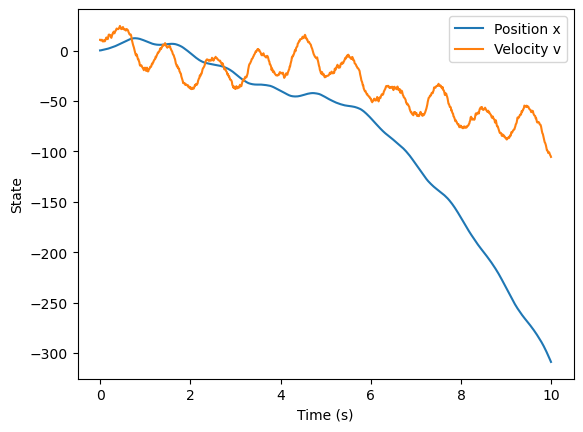

In [40]:
class DiscreteParticleSystem(LeafSystem):
    def __init__(self, dt: float = 0.01, g: float = -9.8):
        # TODO: 继承
        super().__init__()
        # TODO: 传入参数
        self.dt = dt
        self.gravity = g
        # TODO: 声明离散状态（vector [x, v]，初始 [0, 0]）
        self.DeclareDiscreteState(2)
        
        # TODO: 声明输入端口（scalar u）
        self._input_port = self.DeclareVectorInputPort(name="u", size=1) # type: ignore
        
        # TODO: 声明输出端口（vector [x, v]）
        self.DeclareVectorOutputPort(name="state", size=2, calc=self.DoCalcVectorOutput) # type: ignore
        
        # TODO: 声明离散更新事件（每 dt 秒更新一次）
        self.DeclarePeriodicDiscreteUpdateEvent(
            period_sec=self.dt, 
            offset_sec=0.0, 
            update=self.DoCalcDiscreteVariableUpdates) # type: ignore

    def DoCalcDiscreteVariableUpdates(self, context: Context, discrete_state):
        # 获取当前状态和输入
        x = context.get_discrete_state_vector().GetAtIndex(0)
        v = context.get_discrete_state_vector().GetAtIndex(1)

        # current_state = context.get_discrete_state().value() # type: ignore
        u = self.GetInputPort("u").Eval(context)[0] # type: ignore

        # u = self._input_port.Eval(context)[0]
        # print(u)
        # TODO: 计算下一状态
        # x = float(current_state[0])
        # v = float(current_state[1])
        x_next = x + v * self.dt
        v_next = v + (u + self.gravity) * self.dt + np.random.normal(0, 1)
        next_state = np.array([x_next, v_next], dtype=np.float64)
        # 更新 discrete_state
        discrete_state.get_mutable_vector().SetFromVector(next_state)

    def DoCalcVectorOutput(self, context, output):
        # TODO: 输出当前 [x, v]
        current_state = context.get_discrete_state().value()
        output.SetFromVector(current_state)

class GetInputTorque(LeafSystem):
    def __init__(self, frequency:float=1.0, amplitude:float=1.0):
        super().__init__()
        self.frequency = frequency
        self.amplitude = amplitude
        self.DeclareVectorOutputPort(
            name="output_torque",
            size = 1, # type: ignore
            calc=self.CaclOutputTorque
        ) # type: ignore
    
    def CaclOutputTorque(self, context: Context, output: BasicVector):
        t = context.get_time()
        sin_value = self.amplitude * np.sin(2 * np.pi * self.frequency * t)
        # print(sin_value)
        output.SetFromVector([sin_value]) # type: ignore

def run_simulation():
    # TODO: create builder
    builder = DiagramBuilder()

    # 添加你的系统
    particle = builder.AddSystem(DiscreteParticleSystem(dt=0.01))
    
    # TODO: 添加输入源（e.g., sin wave；用 ConstantVectorSource 或自定义系统）
    # 提示：对于 sin(t)，你可以自定义另一个 LeafSystem 输出 sin(2*pi*t)
    # input_source = builder.AddSystem(ConstantVectorSource(source_value=np.array([0.0])))
    input_source = builder.AddSystem(GetInputTorque(frequency=1.0, amplitude=100.0))
    # 连接
    builder.Connect(input_source.get_output_port(0), particle.GetInputPort("u"))
    
    # 构建 diagram
    diagram = builder.Build()
    # 创建 simulator
    simulator = Simulator(diagram)
    context = simulator.get_mutable_context()
    particle_context = diagram.GetMutableSubsystemContext(particle, context)
    
    # TODO: 设置初始状态（e.g., [0, 10]）
    # particle_context.SetDiscreteState(particle.state_index, np.array([0.0, 10.0]))  # type: ignore # 设置初始 [x, v]
    particle_context.get_discrete_state_vector().SetFromVector(np.array([0.0, 10.0]))
    
    # 运行模拟并记录轨迹
    times = []
    states = []
    simulator.Initialize()
    for t in np.arange(0.0, 10.0, 0.01):
        simulator.AdvanceTo(t)
        particle_context = diagram.GetSubsystemContext(particle, simulator.get_context())
        state = particle.GetOutputPort("state").Eval(particle_context) # type: ignore
        times.append(t)
        states.append(state)
    
    # TODO: plot 轨迹
    states = np.array(states)
    plt.plot(times, states[:, 0], label='Position x')
    plt.plot(times, states[:, 1], label='Velocity v')
    plt.xlabel('Time (s)')
    plt.ylabel('State')
    plt.legend()
    plt.show()

if __name__ == "__main__":
    run_simulation()